## Instalando o Dataset

In [7]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Iris.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/iris",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

C:\Users\kombo\AppData\Local\Temp\ipykernel_29616\1921488342.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


1. Vendo algumas métricas gerais, como dados faltantes, tipos de cada column, etc..

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [9]:
# removendo coluna Id, nao precisamos dela
df.drop(['Id'], axis = 1, inplace = True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [12]:
# Dataset em portugues
df_br = df.rename(columns={
    'SepalLengthCm': "ComprimentoSepalaCm",
    'SepalWidthCm': "LarguraSepalaCm",
    'PetalLengthCm': "ComprimentoPetalaCm",
    'PetalWidthCm': "LarguraPetalaCm",
    'Species':"Especies"
}, inplace = False)


In [13]:
df_br.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ComprimentoSepalaCm  150 non-null    float64
 1   LarguraSepalaCm      150 non-null    float64
 2   ComprimentoPetalaCm  150 non-null    float64
 3   LarguraPetalaCm      150 non-null    float64
 4   Especies             150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [48]:
# Retirando a coluna que string (nao conseguimos utilizar medidas de dispersao nem descritiva)
columns = df_br.columns.drop('Especies')
for column in columns:
    print("Medidas descritivas da coluna", column)
    print(f"A média da coluna é de: {df_br[column].mean():.2f}")
    print(f"E a mediana é de: {df_br[column].median():.2f}\n")
    print("Medidas de dispersao")
    print(f"E a variancia é de: {df_br[column].var():.2f}")
    print(f"E o desvio padrao é de: {df_br[column].std():.2f}\n")
    

Medidas descritivas da coluna ComprimentoSepalaCm
A média da coluna é de: 5.84
E a mediana é de: 5.80

Medidas de dispersao
E a variancia é de: 0.69
E o desvio padrao é de: 0.83

Medidas descritivas da coluna LarguraSepalaCm
A média da coluna é de: 3.05
E a mediana é de: 3.00

Medidas de dispersao
E a variancia é de: 0.19
E o desvio padrao é de: 0.43

Medidas descritivas da coluna ComprimentoPetalaCm
A média da coluna é de: 3.76
E a mediana é de: 4.35

Medidas de dispersao
E a variancia é de: 3.11
E o desvio padrao é de: 1.76

Medidas descritivas da coluna LarguraPetalaCm
A média da coluna é de: 1.20
E a mediana é de: 1.30

Medidas de dispersao
E a variancia é de: 0.58
E o desvio padrao é de: 0.76



In [47]:
print(f"A moda da coluna Especies é igual a: {df_br["Especies"].mode()[0]}")

A moda da coluna Especies é igual a: Iris-setosa


<Figure size 640x480 with 0 Axes>

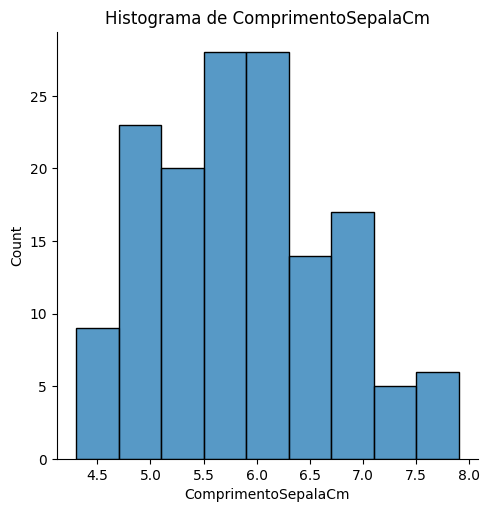

<Figure size 640x480 with 0 Axes>

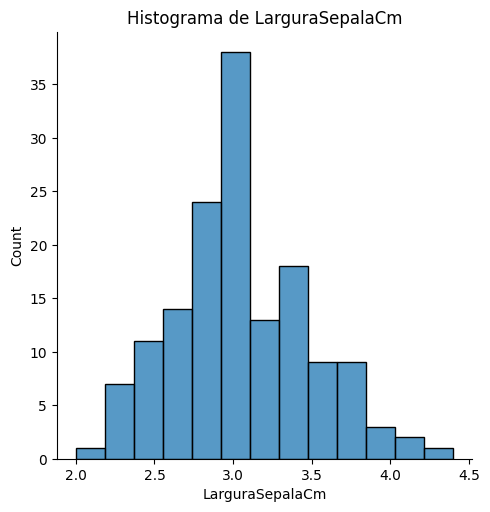

<Figure size 640x480 with 0 Axes>

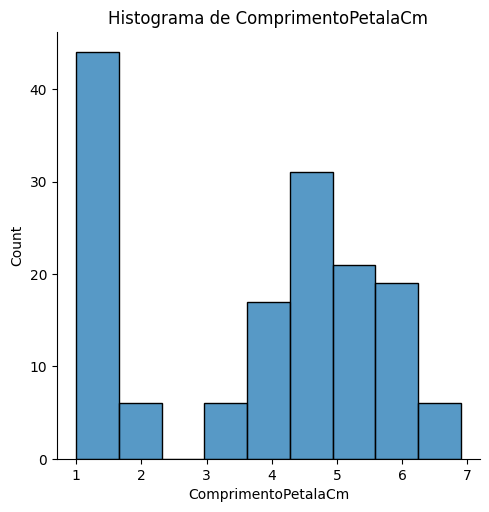

<Figure size 640x480 with 0 Axes>

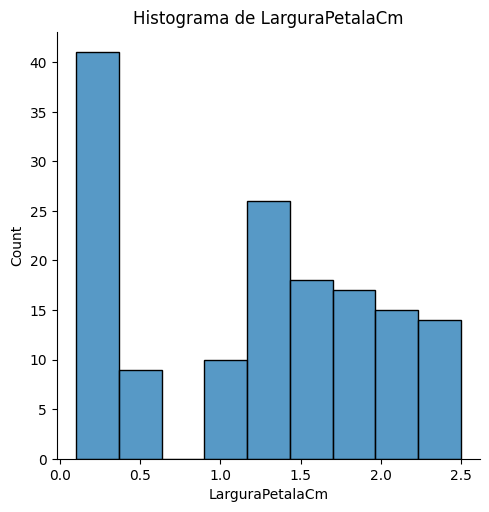

<Figure size 640x480 with 0 Axes>

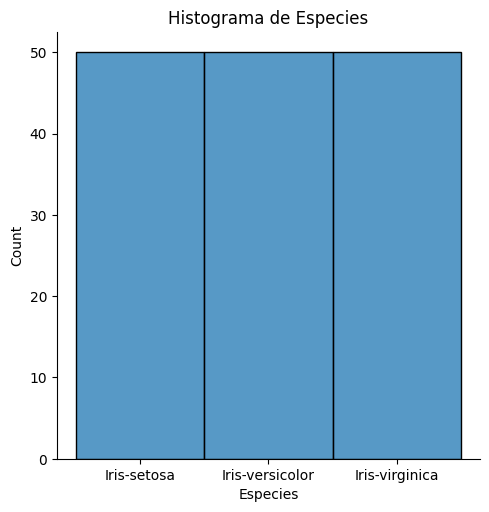

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in df_br.columns:
    plt.figure()
    sns.displot(df_br, x=column)
    plt.title(f"Histograma de {column}")
    plt.show()

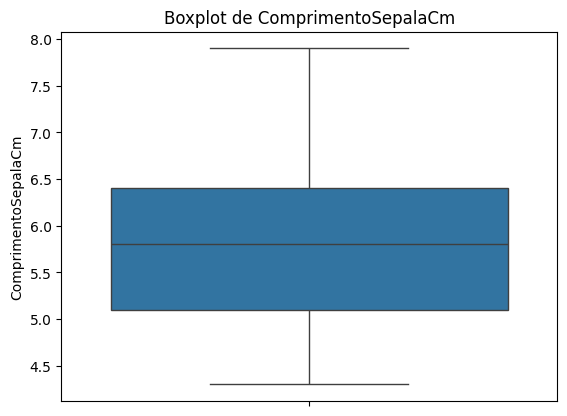

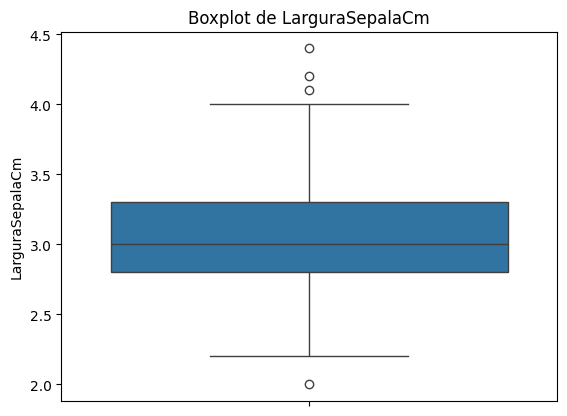

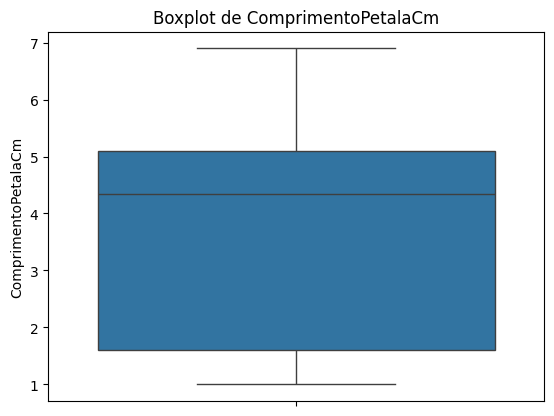

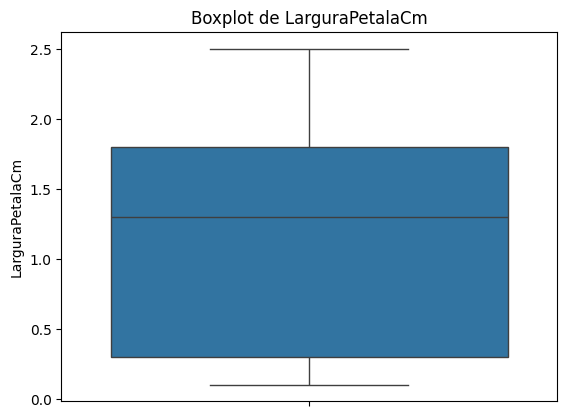

In [54]:
for column in df_br.columns.drop('Especies'):
    plt.figure()
    sns.boxplot(y=df_br[column])
    plt.title(f"Boxplot de {column}")
    plt.show()